##### 25/04/2026 Day(6)

In [24]:
import pandas as pd

In [31]:
df=pd.read_csv("Cleaned_Weather.csv")

# DATA VISUALISATION

### Global Temperature Distribution

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns 


C:\Users\INTERN\AppData\Local\Temp\ipykernel_7456\2241253913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='temperature_celsius', data=year_temp, palette='coolwarm')


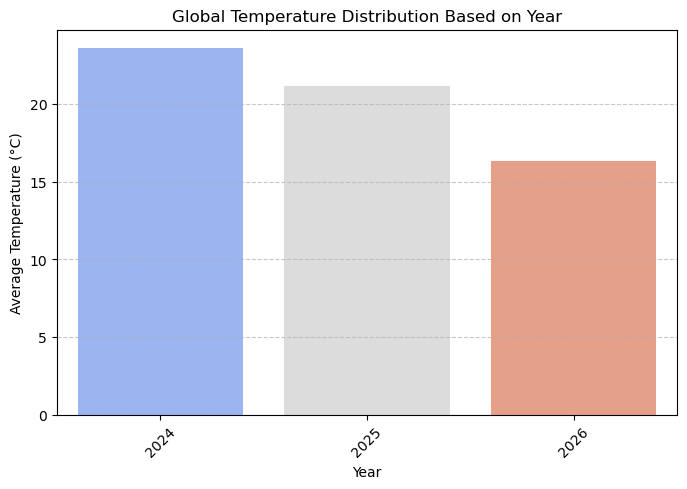

In [45]:
df['date'] = pd.to_datetime(df['date'])
year_temp = df.groupby('year')['temperature_celsius'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='year', y='temperature_celsius', data=year_temp, palette='coolwarm')

plt.title("Global Temperature Distribution Based on Year")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### This bar chart shows the global average temperature distribution based on year. It helps compare yearly temperature changes and identify warming or cooling trends over time. Higher bars indicate higher average temperatures for that year.


### Average Global Level (PM 2.5,PM 10)

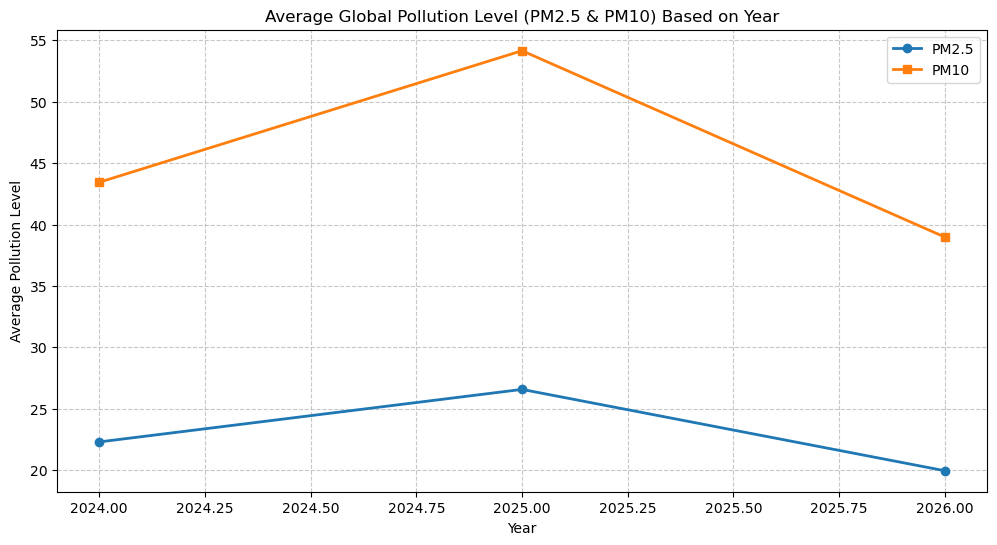

In [48]:
yearly_pm = df.groupby('year')[['air_quality_PM2.5', 'air_quality_PM10']].mean()
plt.figure(figsize=(12,6))

plt.plot(yearly_pm.index, yearly_pm['air_quality_PM2.5'],
         marker='o', linewidth=2, label='PM2.5')

plt.plot(yearly_pm.index, yearly_pm['air_quality_PM10'],
         marker='s', linewidth=2, label='PM10')

plt.title("Average Global Pollution Level (PM2.5 & PM10) Based on Year")
plt.xlabel("Year")
plt.ylabel("Average Pollution Level")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### This chart shows yearly average global PM2.5 and PM10 pollution levels. Higher values indicate higher air pollution.


### Global Air Pollution Trend

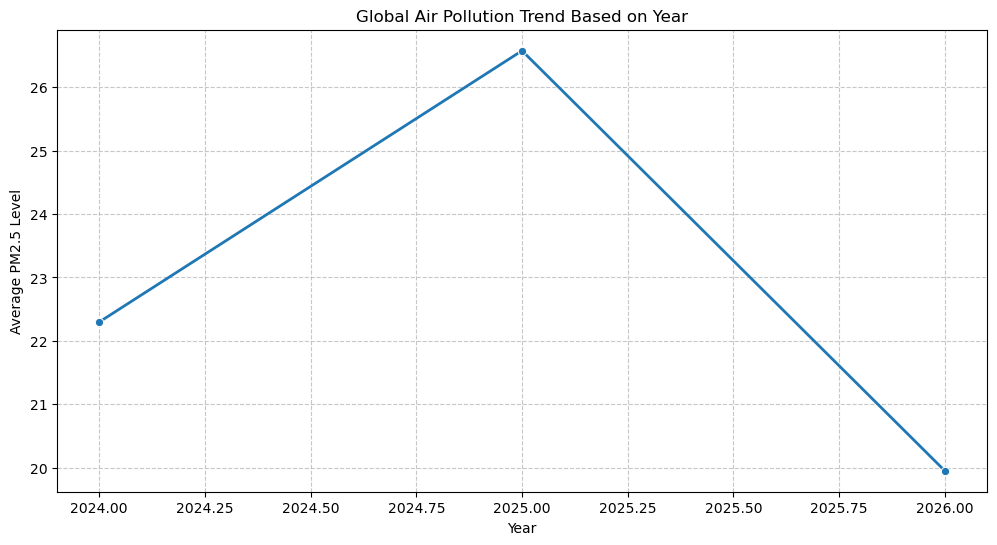

In [46]:
year_pollution = df.groupby('year')['air_quality_PM2.5'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='year', y='air_quality_PM2.5', data=year_pollution, marker='o', linewidth=2)
plt.title("Global Air Pollution Trend Based on Year")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 Level")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### This chart shows yearly global air pollution trends using average PM2.5 levels. Higher values indicate more pollution.


# Weather Conditions

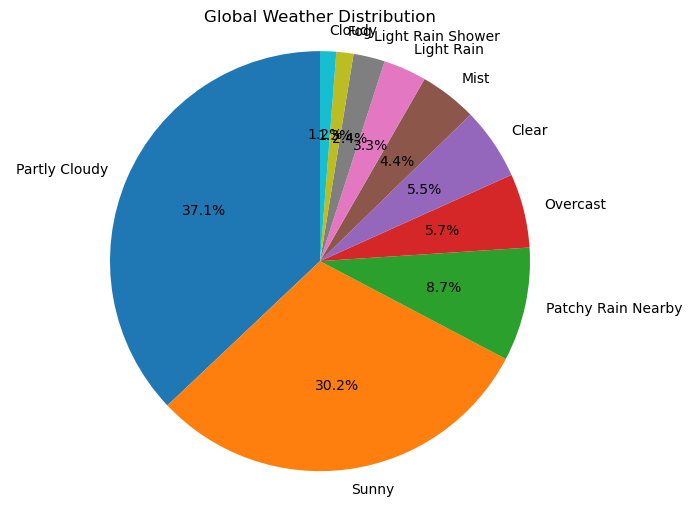

In [73]:
weather_counts = df['condition_text'].value_counts().head(10)   
plt.figure(figsize=(8,6))
plt.pie(weather_counts,
        labels=weather_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Global Weather Distribution")
plt.axis('equal')

plt.show()

##### This pie chart shows the global distribution of weather conditions. It compares the percentage of different weather types across the dataset.


## High Temperature of Top 10 Countries

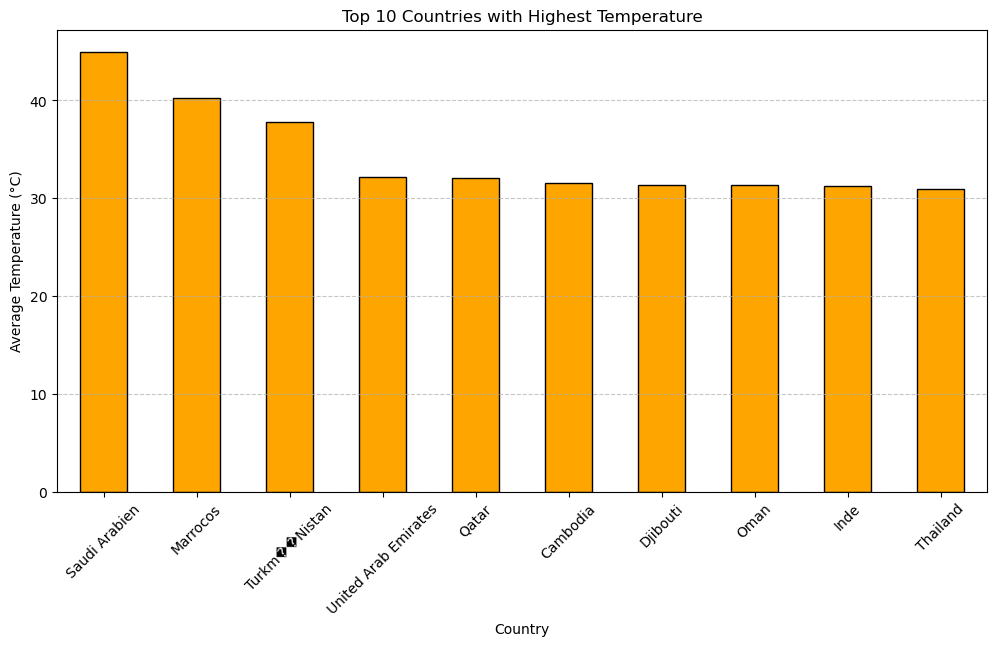

In [52]:
top10_countries = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top10_countries.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Top 10 Countries with Highest Temperature")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### This chart shows the top 10 countries with the highest average temperatures. It helps compare the hottest countries in the dataset.


## Humidity by Top 10 Countries

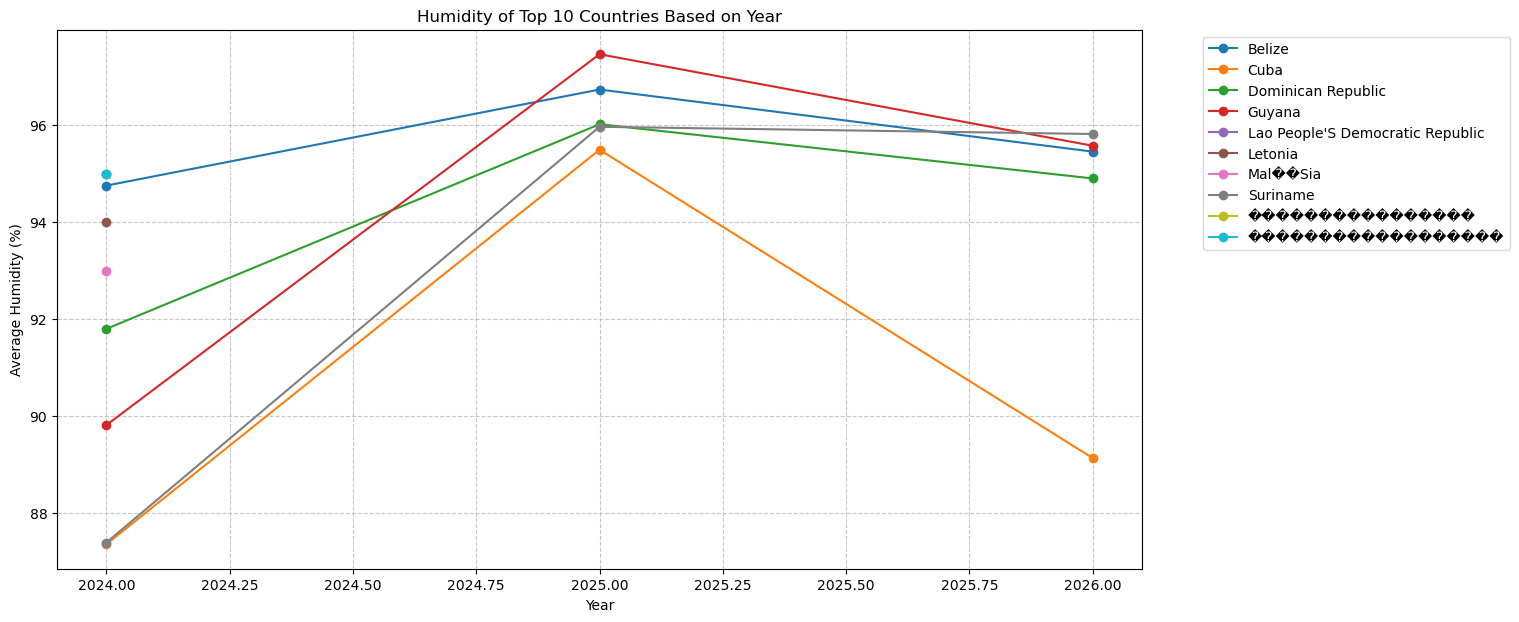

In [60]:

top10_countries = df.groupby('country')['humidity'].mean().sort_values(ascending=False).head(10).index
filtered_df = df[df['country'].isin(top10_countries)]
yearly_humidity = filtered_df.groupby(['year', 'country'])['humidity'].mean().unstack()
plt.figure(figsize=(14,7))

for country in yearly_humidity.columns:
    plt.plot(yearly_humidity.index, yearly_humidity[country], marker='o', label=country)

plt.title("Humidity of Top 10 Countries Based on Year")
plt.xlabel("Year")
plt.ylabel("Average Humidity (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

##### This chart shows yearly average humidity trends for the top 10 most humid countries. It helps compare humidity changes across years.


# High Temperature by Continent

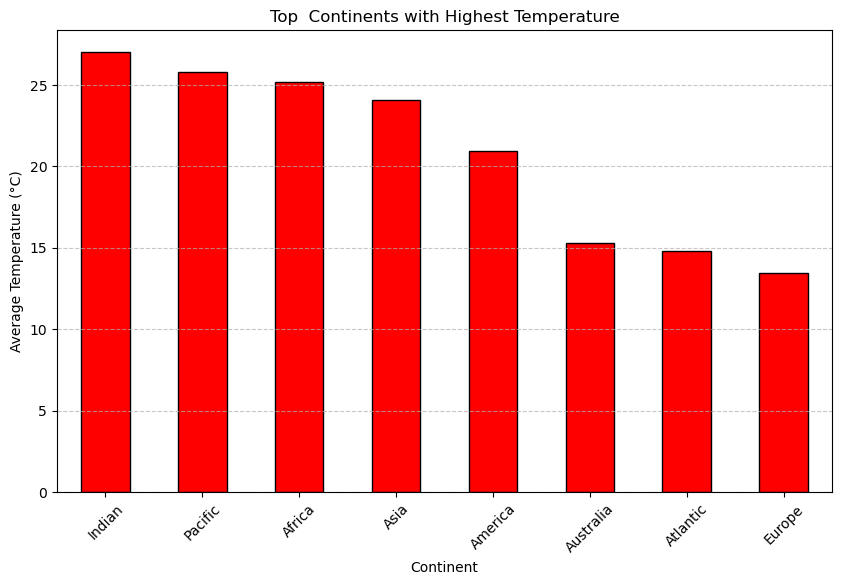

In [55]:
top_continents = df.groupby('continent')['temperature_celsius'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_continents.plot(kind='bar', color='red', edgecolor='black')
plt.title("Top  Continents with Highest Temperature")
plt.xlabel("Continent")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### This chart shows the continents with the highest average temperatures. It helps compare temperature levels across different continents.


## Temperature Distribution In India

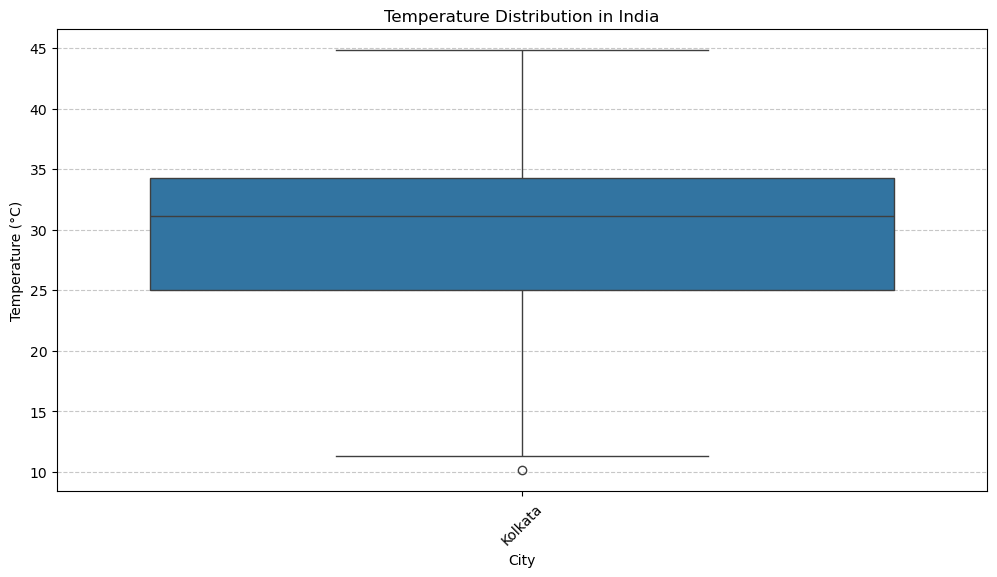

In [62]:
india_df = df[df['country'] == 'India']
plt.figure(figsize=(12,6))
sns.boxplot(x='city', y='temperature_celsius', data=india_df)
plt.title("Temperature Distribution in India")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### This boxplot shows the temperature distribution of Indian cities. It helps compare median temperature, spread, and outliers across locations in India.


# Compare Two Columns

#### Temperature vs Humidity

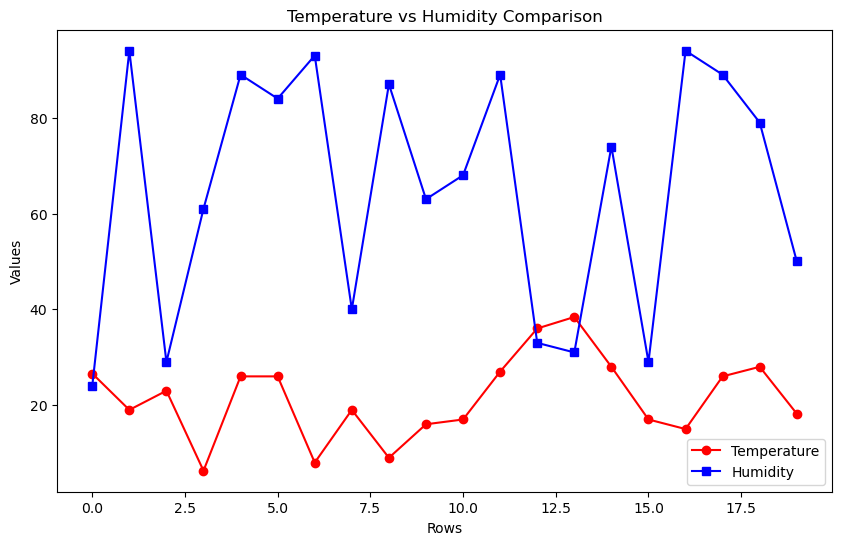

In [64]:
plt.figure(figsize=(10,6))         

plt.plot(df['temperature_celsius'].head(20),
         label='Temperature',
         color='red',
         marker='o')

plt.plot(df['humidity'].head(20),
         label='Humidity',
         color='blue',
         marker='s')

plt.title("Temperature vs Humidity Comparison")
plt.xlabel("Rows")
plt.ylabel("Values")
plt.legend()

## Relationship Between Temperature And Humidity

In [83]:
gf=df.loc[:10]

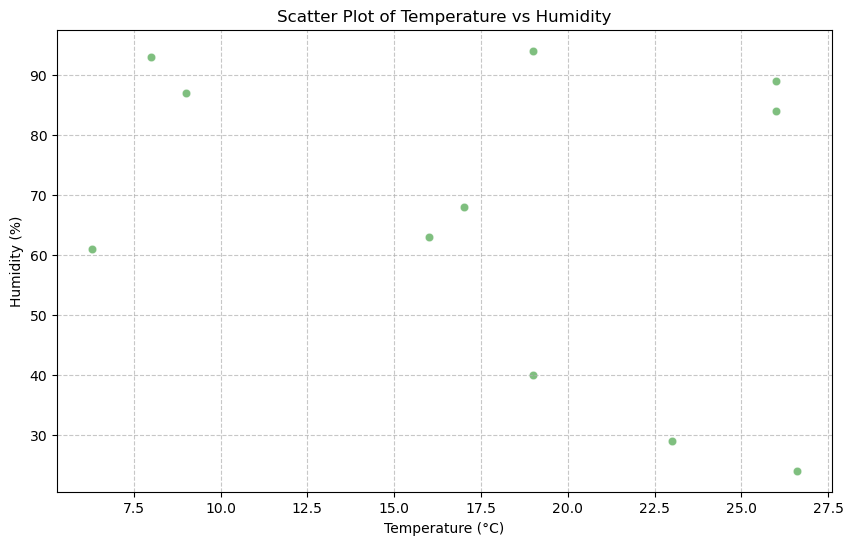

In [96]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='temperature_celsius',
    y='humidity',
    data=gf,
    color='Green',   
    alpha=0.5
    
)

plt.title("Scatter Plot of Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.grid(True, linestyle='--', alpha=0.7,)

plt.show()

##### This scatter plot shows the relationship between temperature and humidity. It helps identify patterns and variation between the two variables.


#  Wind Speed Distribution

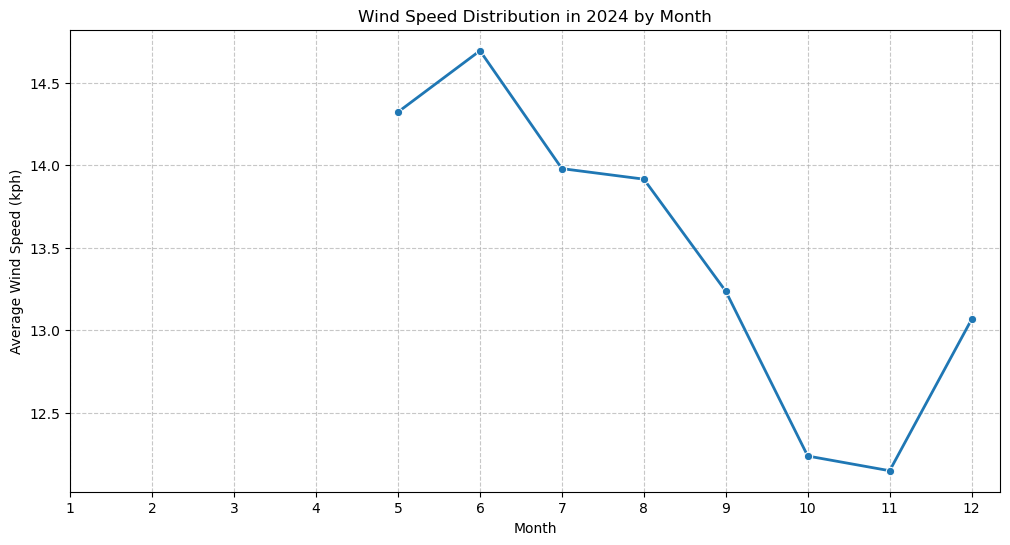

In [66]:
df_2024 = df[df['year'] == 2024]
monthly_wind = df_2024.groupby('month')['wind_kph'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='month', y='wind_kph', data=monthly_wind, marker='o', linewidth=2)
plt.title("Wind Speed Distribution in 2024 by Month")
plt.xlabel("Month")
plt.ylabel("Average Wind Speed (kph)")
plt.xticks(range(1,13))
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

##### This chart shows the monthly average wind speed distribution in 2024. It helps compare wind speed changes across different months.


## Correlation Graph

### Correlation Heatmap Of Environmental Factors

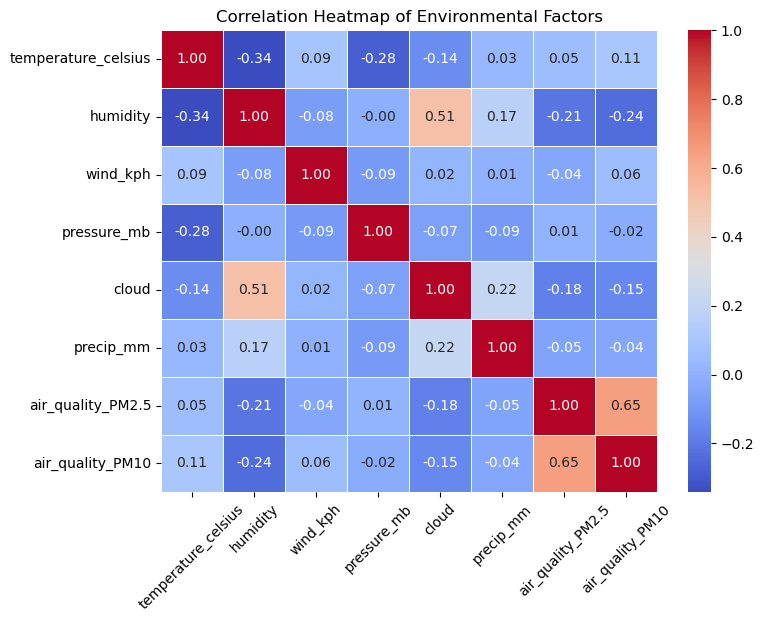

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
env_data = df[['temperature_celsius', 'humidity', 'wind_kph', 
               'pressure_mb', 'cloud', 'precip_mm',
               'air_quality_PM2.5', 'air_quality_PM10']]
corr_matrix = env_data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Environmental Factors")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

##### This heatmap shows the correlation between environmental factors such as temperature, humidity, wind speed, pressure, rainfall, cloud cover, and air pollution. It helps identify positive and negative relationships between variables.


### Average temperature by month and year

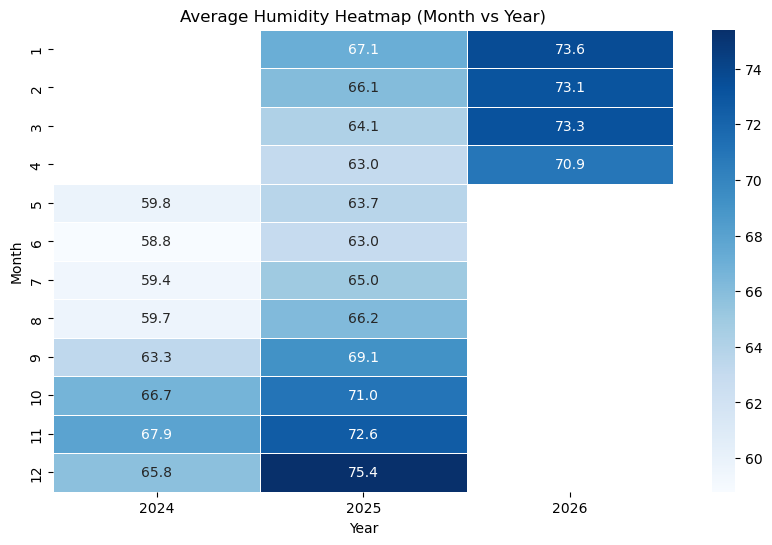

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
heat_data = df.pivot_table(
    values='humidity',
    index='month',
    columns='year',
    aggfunc='mean'
)
plt.figure(figsize=(10,6))
sns.heatmap(heat_data, annot=True, cmap='Blues', fmt='.1f', linewidths=0.5)
plt.title("Average Humidity Heatmap (Month vs Year)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

##### This heatmap shows the average humidity for each month across different years. It helps compare monthly humidity patterns and yearly changes.
